# Illuminating underexplored GPCR dynamics via GPCRmd chemical shift streaming

This notebook provides a step-by-step guide to replicate the analysis outlined in the section, "Illuminating underexplored GPCR dynamics via GPCRmd chemical shift streaming". The workflow includes reading data from CSV files, processing the data, generating histograms, and visualizing protein structures using NGLView. The following sections outline the steps and the corresponding code used in this analysis.

## Table of Contents
1. [Loading and Processing Data](#Loading-and-Processing-Data)
2. [Generating Histograms](#Generating-Histograms)
3. [Visualizing Protein Structures](#Visualizing-Protein-Structures)




### Load Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import statistics
import seaborn as sns
import nglview as nv

### Load Functions

In [2]:
def plot_histogram(numbers_list, labels_list, output_filename, color_types=['red', 'blue']):
    """
    Plots histograms for multiple lists of numerical values on the same plot.
    
    Parameters:
    - numbers_list: A list of lists, where each sublist contains numerical values to be plotted.
    - labels_list: A list of labels corresponding to each sublist in numbers_list.
    - output_filename: The filename where the plot image will be saved.
    - color_types: A list of colors for each histogram (default is ['red', 'blue']).
    
    This function creates a single plot with multiple histograms, each with a different color and label.
    """

    # Set the font family and style globally
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    
    # Create a figure and a single subplot for the histogram
    fig, ax_hist = plt.subplots(figsize=(20, 4))
    
    # Loop through each list of numbers, corresponding label, and color
    for numbers, label, color_type in zip(numbers_list, labels_list, color_types):
        # Plot the histogram for the current set of numbers
        n, bins, patches = ax_hist.hist(numbers, bins=60, density=True, color=color_type, alpha=0.4, label=label)
        
    # Invert the x-axis
    ax_hist.invert_xaxis()
    
    # Adjust the font size of ticks
    ax_hist.tick_params(axis='both', which='major', labelsize=30)
    
    # Set the x-axis limits
    ax_hist.set_xlim(2.23, 1.17)
    
    plt.xlabel('HE CS (ppm)',fontsize=20)
    
    # Save the plot to a file and display it
    plt.savefig('plots/'+output_filename)
    plt.show()
    plt.close()


def process_file(file_path, color_types, exp_values):
    """
    Processes a file containing numerical data, calculates mean values, and generates plots.
    
    Parameters:
    - file_path: The path to the input file.
    - color_types: A list of colors to use for the plots.
    - exp_values: A list of experimental values to be marked on the plots.
    
    Returns:
    A dictionary containing all the numerical values grouped by their respective identifiers.
    """
    # Split the file path to create an output path
    path_frag = file_path.split('.')
    output_path_tmp = path_frag[0]
    output_path = output_path_tmp.split('/')[1]

    # Dictionaries to store mean values and all values for each identifier
    dict_comp_values_mean = {}
    dict_comp_values_all = {}

    # Open the file for reading
    with open(file_path, 'r') as file:
        # Read all lines from the file and skip the first line (header)
        lines = file.readlines()[1:]

        # Process each line
        for line in lines:
            data = line.strip().split(";")
            float_list = [float(element) for element in data[4:]]
            id_key = str(int(data[0]) - 49) + '_' + str(data[2]) + '_' + str(data[1])
            mean_value = statistics.mean(float_list)
            dict_comp_values_mean[id_key] = mean_value
            dict_comp_values_all[id_key] = float_list
        
    return dict_comp_values_all

### Define input parameters

Here we need to describe which are the methionines that we want to plot. In our case, we select the methionines highlighted in the study of Joshua J. Ziarek et al. 

- M250: resid 201

We also define the mean experimental values, extracted from the [publication of Joshua J. Ziarek et al.](https://www.cell.com/cell-reports/fulltext/S2211-1247(23)00026-8).

The user can select the colors for each methionine. The lenght of the list has to match with the lenght of the methionines to evaluate.

Lastly, the user has to specify the path of the CSV file containing the predicted CS values.

In [3]:
# List of labels for the methionines to be screened
to_screen = ['201_MET_HE',]

# List of experimental values corresponding to each methionine
exp_values = [1.66,]

# List of colors corresponding to each methionine in the to_screen list
color_types = ['dodgerblue',]

# File path to the CSV file containing chemical shift values
file_path = 'CS_values/cs_rep1.csv'

### Streaming CS and Histogram accumulation

We create plots to visualize the evolution & distribution of chemical shift values for specified methionines.


#### Replicate 1

In [4]:
file_path = 'CS_values/cs_rep1.csv'
comp_values_rep1 = process_file(file_path,color_types,exp_values)

#### Replicate 2

In [5]:
file_path = 'CS_values/cs_rep2.csv'
comp_values_rep2 = process_file(file_path,color_types,exp_values)

#### Replicate 3

In [6]:
file_path = 'CS_values/cs_rep3.csv'
comp_values_rep3 = process_file(file_path,color_types,exp_values)

### NGL visualization state of M250 (blue)

This section of the code loads a PDB file, visualizes the structure using NGLView, and highlights specific residues with van der Waals spheres.

In [7]:
# Load a PDB file (replace 'protein.pdb' with the actual path to your PDB file)
pdb_path = 'protein.pdb'
view = nv.show_structure_file(pdb_path)  # Create an NGLView viewer for the PDB file

view.clear()  # Clear any existing representations in the viewer

# List of residues to be highlighted, converted to strings (adjust residue numbers as needed)
ngl_residues = [ str(201 + 49),]

count = 0  # Initialize a counter to access the correct color from color_types

# Iterate through the list of residues and add van der Waals spheres for each
for residue_id in ngl_residues:
    selection_string = f'protein and {residue_id}'  # Create a selection string for the current residue
    view.add_spacefill(selection=selection_string, color=color_types[count])  # Add van der Waals spheres with specified color
    count += 1  # Increment the counter to use the next color in the next iteration

# Add a cartoon representation for the protein backbone, colored white
view.add_cartoon(selection='protein', color='white')

# Display the viewer
view

NGLWidget()

### Histograms for M250 (blue)

This section of the code generates and saves histograms for specific methionines from different sets of values (`rep1`, `rep2`, and `rep3`). The histograms are saved as PNG files. This histograms are used for figure 6.


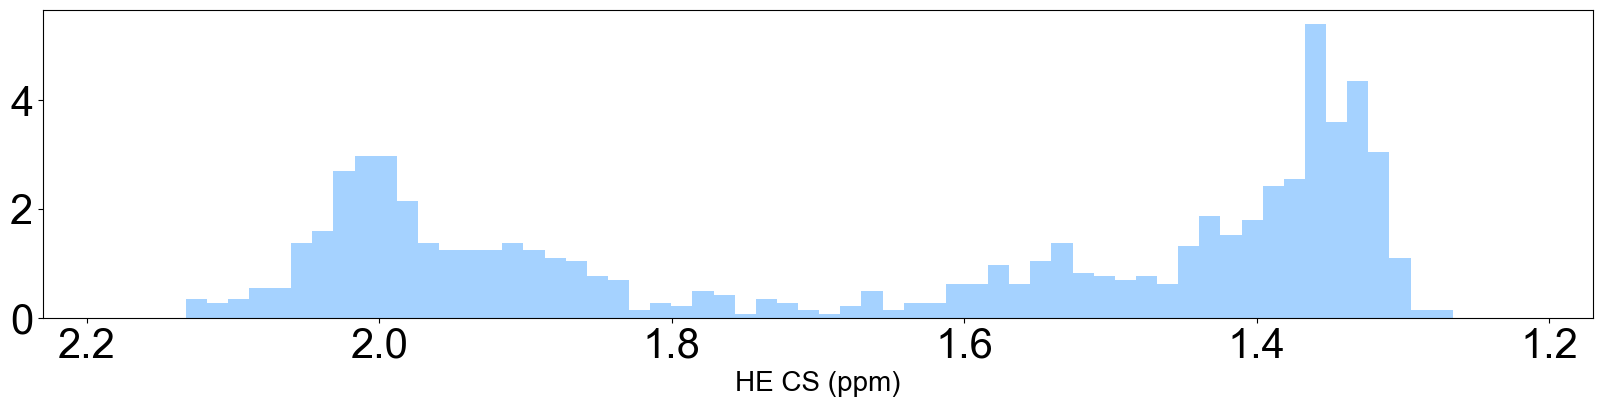

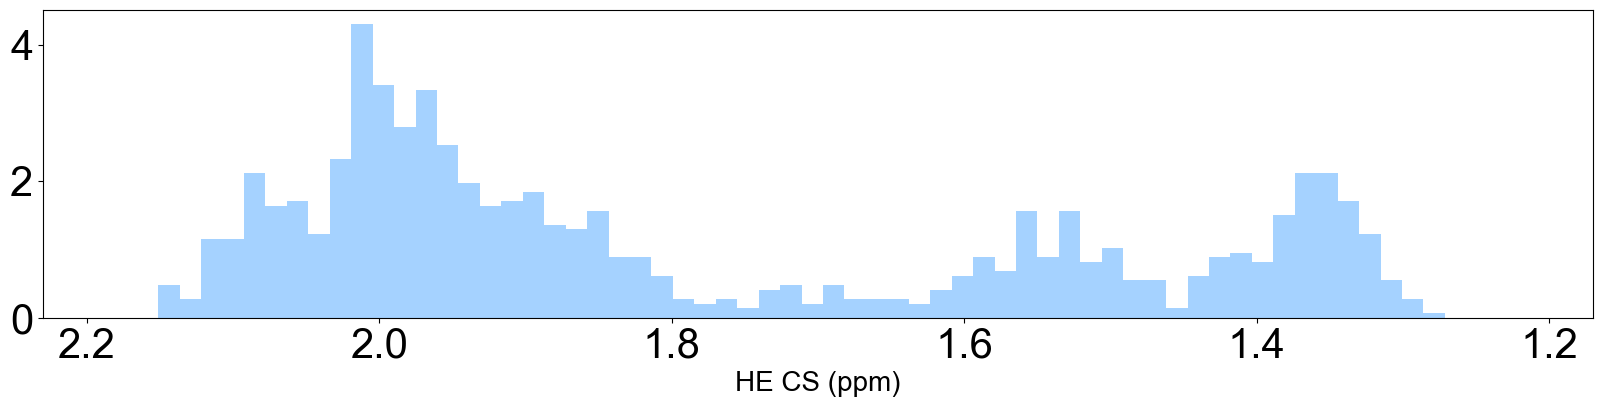

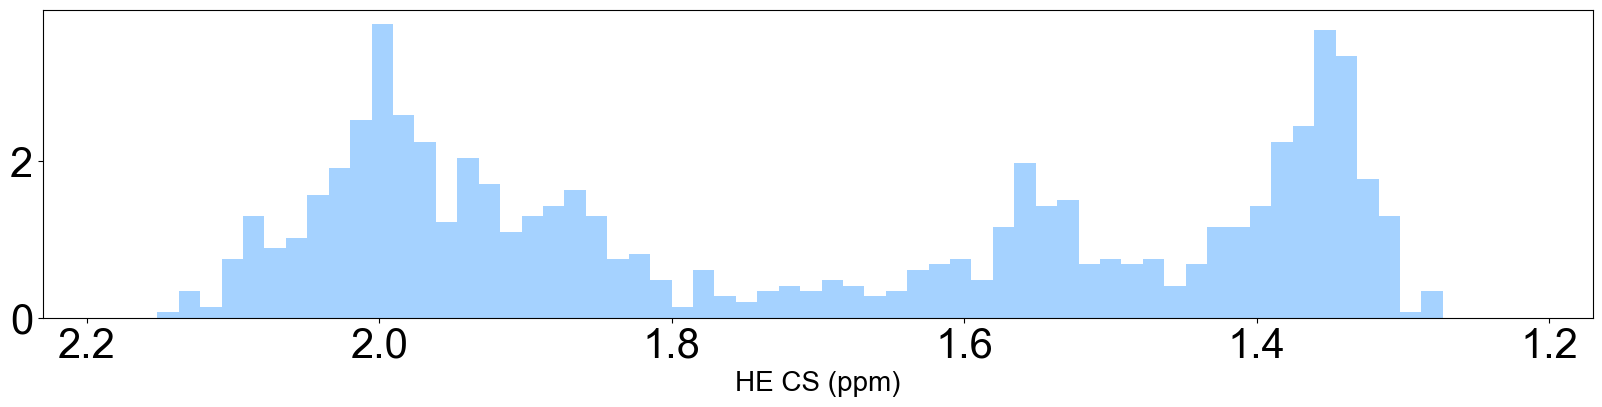

In [8]:
# Plot histograms for the specified metabolites from the first set of values (rep1)
plot_histogram([comp_values_rep1['201_MET_HE'],],  # Lists of values for '201_MET_HE' and '281_MET_HE' from rep1
               ['201_MET_HE',],                                      # Labels for the histograms
               'MET_rep1_histogram.png',                                      # Output filename for the saved plot
               color_types=['dodgerblue',])                              # Colors for the histograms

# Plot histograms for the specified metabolites from the second set of values (rep2)
plot_histogram([comp_values_rep2['201_MET_HE'],],  # Lists of values for '201_MET_HE' and '281_MET_HE' from rep2
               ['201_MET_HE',],                                      # Labels for the histograms
               'MET_rep2_histogram.png',                                      # Output filename for the saved plot
               color_types=['dodgerblue',])                              # Colors for the histograms

# Plot histograms for the specified metabolites from the third set of values (rep3)
plot_histogram([comp_values_rep3['201_MET_HE'],],  # Lists of values for '201_MET_HE' and '281_MET_HE' from rep3
               ['201_MET_HE',],                                      # Labels for the histograms
               'MET_rep3_histogram.png',                                      # Output filename for the saved plot
               color_types=['dodgerblue',])                              # Colors for the histograms
